# Notebook RNN

El objetivo de este notebook es entrenar un modelo de lenguaje a nivel palabra (nuestros tokens van a ser palabras) y una red recurrente simple. Utiliza un fragmento del libro "Don Quijote" como corpus. 

Vamos a usar una RNN muy simple! Hay muchas manera de mejorar esta red 


### Reproducibilidad y dispositivo
- `set_seed(seed)` fija semillas para `numpy`, `random` y `torch`. En GPU puede haber fuentes de no-determinismo (cuDNN), por lo que para reproducibilidad estricta habría que añadir flags adicionales (a costa de rendimiento).
- `find_device()` detecta y usa GPU (CUDA) si está disponible, luego MPS (Apple Silicon) y finalmente CPU.
- `get_data_dir()` intenta escribir en `./data` y si el sistema es de solo lectura usará un directorio temporal.

In [2]:
# ---------------------------
# Imports & utilidades básicas
# ---------------------------
import re
import math
import random
import time
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---------------------------
# Reproducibilidad y dispositivo
# ---------------------------
def set_seed(seed=1234):
    """
    Fija semillas para reproducibilidad (numpy, random y torch).
    Nota: reproducibilidad absoluta en GPU puede requerir flags adicionales.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def find_device():
    """
    Detecta el mejor device disponible:
      CUDA > MPS (Apple) > CPU
    Nota: usamos llamadas correctas a los checkers (con paréntesis).
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

# seleccionar device y fijar semilla global por defecto
DEVICE = find_device()
print("DEVICE:", DEVICE)
SEED = 1234
set_seed(SEED)


DEVICE: mps


####  Preprocesamiento de texto y construcción de vocabulario

En esta sección tokenizamos un pequeño corpus (fragmento de *Don Quijote*) y construimos un vocabulario (símbolo ↔ índice) básico. Este pipeline mínimo es lo necesario para transformar texto en secuencias de enteros que pueden ingresar a modelos como RNNs


##### Tokenización: ¿qué y por qué?

El tokenizador hace lo siguiente: 

- **Minúsculas (lowercasing):** pasa todo a minusculas (por ejemplo "El" y "el" se consideran iguales).
- **Separación de puntuación:** rodeando signos como `, . ; : ! ? ( ) "` con espacios, los tratamos como tokens
  separados. Esto evita que tokens como `vaca,` y `vaca` se consideren distintos.
- **Colapso de espacios:** normaliza espacios en blanco y elimina saltos de línea.


#####  Construcción del vocabulario

La función `build_vocab(tokens, min_freq, reserved_tokens)`:

- Cuenta frecuencia de cada token con `Counter`.
- Incluye solo tokens con frecuencia ≥ `min_freq` (útil para filtrar palabras raras).
- Ordena tokens por frecuencia descendente (y por orden alfabético para empates).
- Prependiza `reserved_tokens` (ej. `<pad>`, `<unk>`) para gestión de padding y OOV.

**Nota:** `min_freq` controla el trade-off vocabulario-size vs cobertura. Un `min_freq` mayor reduce el vocab pero aumenta tokens OOV.

In [ ]:
# ---------------------------
# Corpus
# ---------------------------
# Texto de ejemplo (fragmento del Quijote) que usaremos como corpus mínimo.
text = '''En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo 
de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. Una olla de algo más vaca que carnero, 
salpicón las más noches, duelos y quebrantos los sábados, lentejas los viernes, algún palomino de añadidura los domingos, 
consumían las tres partes de su hacienda.'''

# Imprimir tamaño del texto y una vista previa para verificar
print('Caracteres total:', len(text))
print('Primeros 300 caracteres:\n', text[:300])


# ---------------------------
# Tokenización simple
# ---------------------------
def tokenize(text):
    """
    Tokenizador muy sencillo:
    - pasa todo a minúsculas para reducir vocabulario (case-folding)
    - sustituye saltos de línea por espacio
    - separa signos de puntuación (.,;:!?()") colocando espacios alrededor:
        ejemplo: "hola, mundo" -> "hola , mundo"
      Esto facilita que la puntuación se trate como tokens independientes.
    - colapsa múltiples espacios en uno solo
    - split por espacios
    """
    text = text.lower()                    # case-folding: reduce sparsity por mayúsculas/minúsculas
    text = text.replace('\n', ' ')         # unir líneas
    # rodea signos de puntuación con espacios para que sean tokens separados
    text = re.sub(r'([.,;:!?()\"])', r' \1 ', text)
    # colapsa secuencias de espacios en uno solo y recorta
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split(' ')
    return tokens

# tokenizamos el corpus de ejemplo
tokens = tokenize(text)
print('Número de tokens:', len(tokens))
print('Tokens ejemplo:', tokens[:30])


# ---------------------------
# Construcción del vocabulario
# ---------------------------
def build_vocab(tokens, min_freq=1, reserved_tokens=['<pad>','<unk>']):
    """
    Construye un vocabulario a partir de una lista de tokens.

    Parámetros:
      - tokens: lista de strings (tokens)
      - min_freq: frecuencia mínima para incluir la palabra en el vocabulario
      - reserved_tokens: tokens reservados que van al inicio del vocabulario
          ('<pad>' para padding, '<unk>' para out-of-vocab)

    Retorna:
      - itos: lista index->token (index 0..V-1)
      - stoi: dict token->index
      - counter: Counter con frecuencias originales (útil para análisis)
    """
    counter = Counter(tokens)                       # cuenta apariciones por token
    # selecciona palabras que cumplen min_freq
    words = [w for w,c in counter.items() if c >= min_freq]
    # ordenar por frecuencia descendente (y lexicográficamente como tiebreak)
    words.sort(key=lambda w: (-counter[w], w))
    # construir itos (index->string): primero tokens reservados, luego palabras frecuentes
    itos = list(reserved_tokens) + words
    # construir stoi (string->index)
    stoi = {w:i for i,w in enumerate(itos)}
    return itos, stoi, counter

# construir vocab con min_freq=1 (incluye todo)
itos, stoi, counter = build_vocab(tokens, min_freq=1)
vocab_size = len(itos)
print('Vocab size =', vocab_size)
print('Primeros tokens del vocab:', itos[:20])

Caracteres total: 383
Primeros 300 caracteres:
 En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo 
de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. Una olla de algo más vaca que carnero, 
salpicón las más noches, duelos y quebrantos los sábados, lentejas los viernes, a
Número de tokens: 77
Tokens ejemplo: ['en', 'un', 'lugar', 'de', 'la', 'mancha', ',', 'de', 'cuyo', 'nombre', 'no', 'quiero', 'acordarme', ',', 'no', 'ha', 'mucho', 'tiempo', 'que', 'vivía', 'un', 'hidalgo', 'de', 'los', 'de', 'lanza', 'en', 'astillero', ',', 'adarga']
Vocab size = 54
Primeros tokens del vocab: ['<pad>', '<unk>', ',', 'de', 'los', '.', 'en', 'las', 'más', 'no', 'que', 'un', 'y', 'acordarme', 'adarga', 'algo', 'algún', 'antigua', 'astillero', 'añadidura']


### Dataset para predicción de la siguiente palabra (Next-Token)

En esta celda definimos `NextWordDataset`, un `torch.utils.data.Dataset` que genera pares (contexto, siguiente_token) usando una sliding window sobre el corpus tokenizado. Cada ejemplo tiene longitud fija `seq_len` para el contexto y un único token objetivo.

#### ¿Cómo funciona `NextWordDataset`?

- Convertimos el corpus en una lista de ids (`self.ids`) usando `stoi`.
- Generamos ejemplos con ventana deslizante: para cada índice `i` construimos
  `x = ids[i:i+seq_len]` e `y = ids[i+seq_len]`.
- El número total de ejemplos es `len(ids) - seq_len`. Si esto es ≤ 0, el dataset queda vacío.
- `make_loaders(...)` parte el dataset en train/val de forma reproducible (seed) y devuelve `DataLoader`s.

**Formas de fallo comunes**
- `seq_len` demasiado grande para el corpus → `Dataset vacío`. Reduce `seq_len` o usa más texto.
- No usar `shuffle=True` en el loader de train lleva a órdenes temporales que pueden sesgar el entrenamiento (aunque en LM secuencial a veces se desea mantener orden).

In [5]:
# ---------------------------
# Crear secuencias
# ---------------------------

class NextWordDataset(Dataset):
    """
    Dataset para previsión de la *siguiente palabra* (next-token).
    Cada ejemplo consiste en:
      - X: una secuencia de `seq_len` ids (torch.long) como contexto
      - y: el id (torch.long) del token siguiente

    Notas:
    - Usa indices precomputados (self.ids) para velocidad.
    - El número de ejemplos es len(ids) - seq_len (sliding window no-overflow).
    - Para un corpus corto y seq_len grande, N puede ser 0 (manejamos con ValueError en make_loaders).
    """
    def __init__(self, tokens, stoi, seq_len=5):
        self.seq_len = seq_len
        self.stoi = stoi
        self.tokens = tokens
        self.vocab_size = len(stoi)

        # Convertimos tokens a ids usando stoi (usa <unk> si token no está presente)
        unk_idx = self.stoi.get('<unk>')
        # lista de enteros (ids) equivalente a los tokens del corpus
        self.ids = [self.stoi.get(t, unk_idx) for t in tokens]

        # número de ejemplos posibles: cada posición i genera (ids[i:i+seq_len], ids[i+seq_len])
        # si len(ids) <= seq_len => no hay ejemplos
        self.n = max(0, len(self.ids) - seq_len)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        """
        Devuelve:
          - x: tensor long shape (seq_len,)
          - y: tensor long shape ()
        idx debe estar en [0, self.n-1].
        """
        x = torch.tensor(self.ids[idx:idx+self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx+self.seq_len], dtype=torch.long)
        return x, y

    # utilidad opcional: decodificar un ejemplo a tokens legibles
    def decode_example(self, idx):
        """Devuelve (tokens_context, token_target) legible por humanos para el ejemplo idx."""
        if idx < 0 or idx >= self.n:
            raise IndexError("idx fuera de rango")
        ctx_ids = self.ids[idx:idx+self.seq_len]
        tgt_id = self.ids[idx+self.seq_len]
        # construir reverse map (si no se proporciona externamente)
        itos = {i:w for w,i in self.stoi.items()}
        ctx_tokens = [itos.get(i, '<unk>') for i in ctx_ids]
        tgt_token = itos.get(tgt_id, '<unk>')
        return ctx_tokens, tgt_token

# ---------------------------
# Prueba rápida
# ---------------------------
SEQ_LEN = 6
ds = NextWordDataset(tokens, stoi, seq_len=SEQ_LEN)
print('Dataset tamaño:', len(ds))
if len(ds) > 0:
    xb0, yb0 = ds[0]
    print('Ejemplo X (ids):', xb0.tolist())
    print('Ejemplo y (id):', int(yb0.item()), '-> token:', itos[int(yb0.item())])
else:
    print("Dataset vacío: reduce seq_len o usa más texto.")

# ---------------------------
# Creación de loaders (train/val split)
# ---------------------------
def make_loaders(tokens, stoi, seq_len=6, batch_size=64, val_frac=0.2, seed=1234):
    """
    Crea DataLoaders de entrenamiento y validación a partir del corpus tokenizado.
    - val_frac: fracción del dataset usada como validación (p.ej. 0.2)
    - seed: semilla para shuffle reproducible del split
    - Devuelve: train_loader, val_loader (DataLoader)
    """
    dataset = NextWordDataset(tokens, stoi, seq_len=seq_len)
    N = len(dataset)
    if N == 0:
        raise ValueError('Dataset vacío: reduce seq_len o usa más texto.')

    # índices y mezcla reproducible
    rng = np.random.RandomState(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    # partición
    n_val = max(1, int(val_frac * N))
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    # Subset para evitar copiar datos del dataset original
    from torch.utils.data import Subset
    train_ds = Subset(dataset, train_idx)
    val_ds = Subset(dataset, val_idx)

    # DataLoaders con shuffle sólo en train; collate default funciona porque todas las secuencias tienen la misma longitud
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

# ---------------------------
# Uso de ejemplo: crear loaders y ver shapes
# ---------------------------
train_loader, val_loader = make_loaders(tokens, stoi, seq_len=SEQ_LEN, batch_size=16, val_frac=0.2)
print('Batches train:', len(train_loader), 'batches val:', len(val_loader))
for xb, yb in train_loader:
    print('xb shape:', xb.shape, 'yb shape:', yb.shape)
    # xb shape == (batch_size, seq_len), yb shape == (batch_size,)
    break


Dataset tamaño: 71
Ejemplo X (ids): [6, 11, 34, 3, 31, 35]
Ejemplo y (id): 2 -> token: ,
Batches train: 4 batches val: 1
xb shape: torch.Size([16, 6]) yb shape: torch.Size([16])


### SimpleRNNLM — modelo RNN para next-token

Hemos definido `SimpleRNNLM` que consiste en:
- `nn.Embedding(vocab_size, embed_dim)` para convertir ids a vectores densos.
- `nn.RNN` (vanilla, nonlinearity='tanh') con `batch_first=True` para procesar secuencias (B, T, D).
- `nn.Linear(hidden_size, vocab_size)` que proyecta la última salida temporal a logits sobre el vocabulario.


### Métrica: perplexity

Para modelos de lenguaje la métrica estándar es **perplexity**:

\[
\text{perplexity} = \exp(\text{cross-entropy loss})
\]

- Intuición: perplexity es la "cantidad efectiva de opciones" que el modelo considera en promedio.  
  Por ejemplo, `perplexity = 10` significa que, en promedio, el modelo está tan inseguro como si tuviera que elegir entre 10 opciones igualmente probables.
- Reglas prácticas:
  - `perp ≈ 1` → casi determinista (irreal en corpora reales).
  - `perp` alto → modelo incierto / pobre.
- Atención: la escala de perplexity depende de la tokenización y del vocabulario; al cambiar tokenización (char vs subword) las cifras no son directamente comparables.



In [7]:
# ---------------------------
# Modelo RNN simple para language modeling (next-token)
# ---------------------------
class SimpleRNNLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_layers=1, dropout=0.0):
        """
        Modelo RNN muy simple para next-token:
        - Embedding: ids -> vectores (embed_dim)
        - RNN vanilla (tanh) con batch_first=True
        - Linear final para proyectar hidden -> logits sobre vocab
        """
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(input_size=embed_dim,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          nonlinearity='tanh',
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        """
        x: LongTensor shape (B, T)
        retorna logits shape (B, V) correspondiendo al siguiente token después de la ventana.
        """
        emb = self.embed(x)             # (B, T, embed_dim)
        out, h_n = self.rnn(emb)        # out: (B, T, hidden)
        last = out[:, -1, :]            # (B, hidden) — usar la última salida temporal
        logits = self.fc(last)          # (B, vocab_size)
        return logits


### Entrenamiento y evaluación

Esta celda contiene el bucle de entrenamiento principal (`train_loop`) que:
- entrena el modelo por `epochs` épocas,
- aplica **gradient clipping** para estabilizar RNNs,
- evalúa al final de cada época tanto en *train* como en *val*,
- calcula y registra **perplexity** (`exp(loss)`) además de loss y accuracy.

Guardar el `history` permite trazar curvas de `train_perp` y `val_perp` para diagnosticar under/overfitting en modelos de lenguaje.

### ¿Qué hace cada parte del código?

- `model.train()` activa dropout y otro comportamiento de entrenamiento.
- Dentro del bucle batch:
  - `optim.zero_grad()` limpia los gradientes acumulados.
  - `loss.backward()` calcula los gradientes por backprop.
  - `clip_grad_norm_` evita gradientes explosivos (útil en RNNs/LSTMs).
  - `optim.step()` actualiza parámetros.
- Al terminar la época, usamos `evaluate()` para obtener métricas más estables y completas:
  - `train_perp` y `val_perp` son las perplexities (exp de la loss promedio).
  - `train_acc` / `val_acc` dan una medida adicional de performance.
- Guardamos todo en `history` para graficar y comparar configuraciones.


In [15]:
# ---------------------------
# Bucle de entrenamiento: registra perplexity (train/val) por época
# ---------------------------
def train_loop(model, train_loader, val_loader, device, epochs=10, lr=1e-2, clip=1.0, optimizer_name='SGD'):
    """
    Entrena el modelo y registra métricas por época:
      - train_loss, val_loss
      - train_perp, val_perp  (perplexity = exp(loss))
      - train_acc, val_acc

    Parámetros:
      - model: nn.Module (moverá el modelo a `device`)
      - train_loader, val_loader: DataLoader con (xb, yb)
      - device: 'cpu' o 'cuda' (torch.device)
      - epochs: número de épocas de entrenamiento
      - lr: learning rate
      - clip: valor para clip_grad_norm_ (norm clipping)
      - optimizer_name: 'SGD' o cualquier cadena que empiece con 'adam' para usar Adam
    """
    # mover el modelo al device (CPU/GPU/MPS)
    model = model.to(device)

    # criterio de pérdida: CrossEntropy para clasificación next-token
    loss_fn = nn.CrossEntropyLoss()

    # elegir optimizador: Adam si el nombre empieza por 'adam', sino SGD con momentum
    if optimizer_name.lower().startswith('adam'):
        optim = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # historial donde guardaremos métricas por época
    history = {
        'train_loss': [], 'val_loss': [],
        'train_perp': [], 'val_perp': [],
        'train_acc': [], 'val_acc': []
    }

    # bucle principal de épocas
    for ep in range(1, epochs + 1):
        model.train()                # activar modo entrenamiento (dropout, batchnorm, etc.)
        t0 = time.time()             # medir tiempo por época
        running_loss = 0.0           # acumulador de loss * n_examples (opcional)
        n_examples = 0               # contador de ejemplos procesados (batch-wise)

        # iterar sobre batches de entrenamiento
        for xb, yb in train_loader:
            # mover batch al device
            xb = xb.to(device)
            yb = yb.to(device)

            optim.zero_grad()          # limpiar gradientes del optimizador
            logits = model(xb)         # forward: logits shape (B, V)
            loss = loss_fn(logits, yb) # loss escalar (promedio del batch)
            loss.backward()            # backprop: computa gradientes

            # clipping de gradiente: evita exploding gradients en RNNs
            # clip es la norma L2 máxima permitida
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optim.step()               # paso del optimizador (actualiza parámetros)

            # acumular para diagnóstico (no usado para métricas finales, solo para info local)
            running_loss += loss.item() * xb.size(0)
            n_examples += xb.size(0)

        # Al final de la época evaluamos de forma completa (train & val) usando evaluate()
        # evaluate debe devolver (loss_avg, perplexity, accuracy)
        train_loss, train_perp, train_acc = evaluate(model, train_loader, device)
        val_loss, val_perp, val_acc = evaluate(model, val_loader, device)

        # guardamos en el historial para poder graficar luego
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_perp'].append(train_perp)
        history['val_perp'].append(val_perp)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # impresión resumen por época: tiempo y métricas clave (mostramos perplexity y val_acc)
        print(f'Epoch {ep}/{epochs}  time={time.time()-t0:.1f}s  '
              f'train_perp={train_perp:.3f}  val_perp={val_perp:.3f}  val_acc={val_acc:.4f}')

    # retornar el historial para análisis posterior (plots, checkpoints, etc.)
    return history


### Evaluación del modelo: pérdida, perplexity y accuracy

En esta sección evaluamos el modelo en el conjunto de validación (o test).  
La función `evaluate` calcula:
- **loss_avg**: pérdida cross-entropy promedio por ejemplo,
- **perplexity**: `exp(loss_avg)` (métrica estándar para language models),
- **accuracy**: fracción de predicciones correctas del siguiente token.

Antes de entrenar relanzamos un `train_loop` de ejemplo que guarda el historial (perplexities por época).

## ¿Qué mirar en la evaluación?

- **Perplexity** en validación: métrica principal. Si baja con las épocas => el modelo mejora.
- Si **train_perp** baja rápido pero **val_perp** no mejora o sube → *overfitting*.
- Si ambas se estancan altas → underfitting o LR mal ajustado.
- **Accuracy** como complemento: para problemas de LM la perplexity suele ser más informativa que la accuracy del siguiente token.
- Siempre acompaña números con ejemplos generados (muestras) para evaluación cualitativa.


In [20]:
# ---------------------------
# Evaluación: pérdida promedio, perplexity y accuracy
# ---------------------------
import math
import torch
import torch.nn as nn

def evaluate(model, loader, device):
    """
    Evalúa `model` sobre `loader`.
    Retorna una tupla:
      - loss_avg: pérdida promedio por ejemplo (CrossEntropy)
      - perp: perplexity = exp(loss_avg)
      - acc: accuracy (fracción de predicciones correctas)

    Notas:
      - Se asume que cada ejemplo del loader tiene un único target y que
        model(xb) devuelve logits con shape (B, V) para el siguiente token.
      - Usamos torch.no_grad() para no calcular gradientes durante la evaluación.
    """
    # Poner el modelo en modo evaluación (desactiva dropout, batchnorm en modo entrenamiento, etc.)
    model.eval()

    # Definir la función de pérdida (CrossEntropy espera logits y targets int64)
    loss_fn = nn.CrossEntropyLoss()

    # Acumuladores
    total_loss = 0.0       # suma de (loss_batch * batch_size)
    total_examples = 0     # número total de ejemplos contados
    correct = 0            # contador de predicciones correctas

    # No necesitamos gradientes en evaluación: ahorra memoria y tiempo
    with torch.no_grad():
        for xb, yb in loader:
            # mover batch al device (CPU/GPU/MPS)
            xb = xb.to(device)
            yb = yb.to(device)

            # Forward: obtener logits predichos por el modelo (B, V)
            logits = model(xb)

            # Calcular loss promedio sobre el batch (escala a float)
            loss = loss_fn(logits, yb)

            # Acumular loss multiplicado por tamaño del batch para luego promediar correctamente
            total_loss += loss.item() * xb.size(0)

            # Obtener predicciones (índice con máxima probabilidad)
            preds = logits.argmax(dim=-1)   # shape (B,)

            # Contar aciertos
            correct += (preds == yb).sum().item()

            # Aumentar contador de ejemplos
            total_examples += xb.size(0)

    # Si no hay ejemplos (p. ej. loader vacío), devolver NaNs para no falsear métricas
    if total_examples == 0:
        return float('nan'), float('nan'), float('nan')

    # Cálculo de la pérdida promedio por ejemplo
    loss_avg = total_loss / total_examples

    # Calcular perplexity = exp(loss_avg). Capturamos overflow si ocurre.
    try:
        perp = math.exp(loss_avg)
    except OverflowError:
        perp = float('inf')

    # Accuracy como fracción de predicciones correctas
    acc = correct / total_examples

    return loss_avg, perp, acc


# ---------------------------
# Verificaciones rápidas antes de entrenar
# ---------------------------
missing = []
for name in ['model', 'train_loader', 'val_loader', 'DEVICE', 'train_loop']:
    # comprobar que las variables/funciones existen en el entorno global
    if name not in globals():
        missing.append(name)
if missing:
    # si falta algo, lanzar un error claro indicando qué falta
    raise RuntimeError(f"Faltan en el entorno las siguientes variables/funciones: {missing}. Asegúrate de definirlas y ejecutar las celdas previas.")

# ---------------------------
# Hiperparámetros y lanzamiento del entrenamiento
# ---------------------------
EPOCHS = 6
LR = 1e-2
CLIP = 1.0
OPTIM = 'SGD'   # 'SGD' o 'Adam'

# Ejecutar el bucle de entrenamiento definido previamente; `train_loop` registra perplexity por época
history = train_loop(model,
                     train_loader,
                     val_loader,
                     device=DEVICE,
                     epochs=EPOCHS,
                     lr=LR,
                     clip=CLIP,
                     optimizer_name=OPTIM)

# ---------------------------
# Evaluación final rápida en validación
# ---------------------------
val_loss, val_perp, val_acc = evaluate(model, val_loader, DEVICE)
print(f"\nEvaluación final (validación) — Loss: {val_loss:.4f}, Perplexity: {val_perp:.3f}, Accuracy: {100*val_acc:.2f}%")


Epoch 1/6  time=0.1s  train_perp=26.396  val_perp=61.363  val_acc=0.0000
Epoch 2/6  time=0.0s  train_perp=24.180  val_perp=61.936  val_acc=0.0000
Epoch 3/6  time=0.0s  train_perp=21.473  val_perp=62.755  val_acc=0.0000
Epoch 4/6  time=0.0s  train_perp=18.660  val_perp=63.782  val_acc=0.0000
Epoch 5/6  time=0.0s  train_perp=16.018  val_perp=65.045  val_acc=0.0000
Epoch 6/6  time=0.0s  train_perp=13.653  val_perp=66.608  val_acc=0.0000

Evaluación final (validación) — Loss: 4.1988, Perplexity: 66.608, Accuracy: 0.00%


## Curvas de *perplexity* (train / val)

- En la gráfica vemos `train_perp` y `val_perp` por época en escala logarítmica.  
- El modelo aprende bien los ejemplos de entrenamiento (la pérdida y la perplexity de train bajan continuamente), pero no mejora en validación: la pérdida y la perplexity de val se mantienen altas e incluso suben ligeramente. Esto es una señal clásica de overfitting.



1. Perplexity (escala log)
- train_perp baja de forma sostenida (por ejemplo ~25 → ~12), lo que indica que el modelo asigna probabilidades cada vez más concentradas a los tokens correctos en el conjunto de entrenamiento.
- val_perp está mucho más alta (≈ 60) y se incrementa ligeramente con las épocas (≈ 61 → 66).
- Interpretación: el modelo mejora su capacidad para predecir el siguiente token en entrenamiento, pero su capacidad predictiva para datos no vistos no mejora sino que  empeora!!

2. Loss (cross-entropy)
- train_loss desciende de forma clara (≈3.27 → 2.6), coherente con la caída de train_perp.
- val_loss está estable o sube levemente (≈4.12 → 4.20).
- Esto reafirma el diagnóstico: la pérdida en entrenamiento mejora, la pérdida en validación no; el modelo está memorizando patrones de entrenamiento que no generalizan.

#### ¿Por qué ocurre esto? 
- Overfitting / capacidad excesiva: el modelo tiene suficiente capacidad para reducir el error en train pero no generaliza a ejemplos nuevos.
- Corpus pequeño / poca variedad: con un corpus reducido (o pocas muestras útiles), es fácil que el modelo aprenda idiosincrasias del conjunto de entrenamiento.
- Regularización insuficiente: falta de dropout, weight decay, o early stopping permiten que el modelo adapte en exceso sus parámetros.

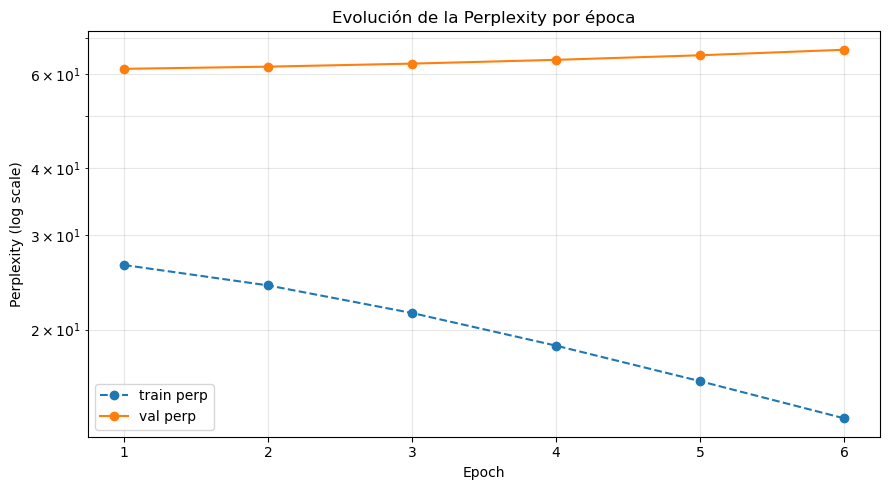

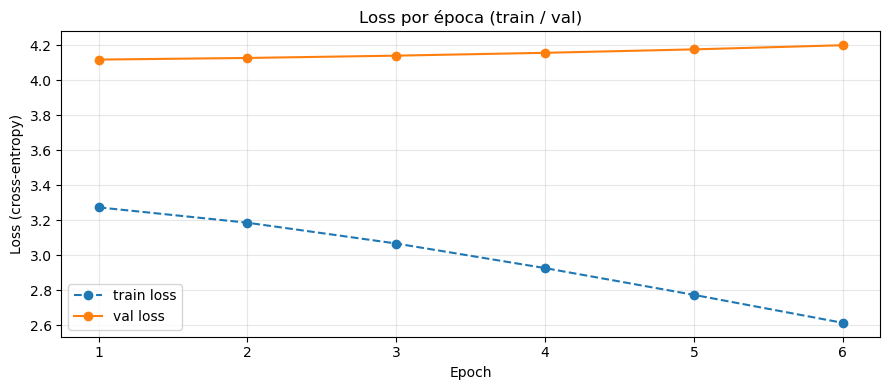

In [21]:
# ---------------------------
# Graficar perplexity por época (train vs val) en escala log
# ---------------------------
import matplotlib.pyplot as plt
import numpy as np

# comprobaciones básicas
if 'history' not in globals():
    raise RuntimeError("La variable 'history' no existe. Ejecuta el entrenamiento primero (train_loop).")

# comprobar que las claves existen
for key in ['train_perp', 'val_perp']:
    if key not in history:
        raise RuntimeError(f"history no contiene '{key}'. Keys disponibles: {list(history.keys())}")

train_perp = history['train_perp']
val_perp = history['val_perp']
epochs = np.arange(1, len(train_perp) + 1)

plt.figure(figsize=(9,5))
plt.plot(epochs, train_perp, '--o', label='train perp')
plt.plot(epochs, val_perp,   '-o', label='val perp')
plt.yscale('log')                     # escala logaritmica en Y
plt.xlabel('Epoch')
plt.ylabel('Perplexity (log scale)')
plt.title('Evolución de la Perplexity por época')
plt.grid(True, which='both', alpha=0.3)
plt.xticks(epochs)
plt.legend()
plt.tight_layout()
plt.show()

# Opcional: graficar pérdidas (si están en history)
if 'train_loss' in history and 'val_loss' in history:
    plt.figure(figsize=(9,4))
    plt.plot(epochs, history['train_loss'], '--o', label='train loss')
    plt.plot(epochs, history['val_loss'],   '-o', label='val loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss (cross-entropy)')
    plt.title('Loss por época (train / val)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Generación autoregresiva con `sample`

La función `sample` genera texto token a token condicionada a una semilla (`seed_seq`).  
Flujo general:
1. Convertimos la semilla a ids y construimos un tensor con batch size 1: `cur` (shape `(1, T)`).
2. Repetimos hasta `max_len`:
   - calculamos logits del siguiente token con el modelo,
   - aplicamos *temperature* (dividimos logits por `temperature`),
   - opcionalmente truncamos a `top_k` logits,
   - aplicamos `softmax` para obtener probabilidades y sampleamos un token,
   - actualizamos la ventana de contexto `cur` usando los últimos `T` tokens generados.
3. Devolvemos la secuencia `seed + generados` como string.

### Parámetros clave de `sample` y su interpretación

- **temperature** (float > 0): ajusta la entropía de la distribución.
  - `temperature < 1` → distribuciones más afiladas → muestreo más determinista (menos diversidad).
  - `temperature > 1` → distribuciones más planas → más diversidad, más errores posibles.
- **top_k** (int o None): restringe las opciones al top-k más probables antes del softmax. Reduce palabras raras/absurdas.
- **max_len**: tokens máximos a generar (controla longitud de la muestra).
- **device**: ejecutar en GPU (`'cuda'`) si está disponible para velocidad.

### Tips: 

- Evita `temperature = 0` (división por cero); la implementación protege con `max(1e-8, temperature)`, pero mejor asegurarse `temperature>0`.
- `top_k` y `temperature` combinados funcionan bien: `top_k=10` + `temperature=0.8` suele dar textos más coherentes.
- La generación es estocástica: para reproducibilidad fija la semilla de PyTorch/numpy si necesitas resultados determinísticos.
- Para mayor calidad de texto se prefiere:
  - models entrenados mucho más tiempo en corpus grande,
  - sampling con nucleus/top-p o beam search para tareas deterministas.
- `sample` asume que el modelo predice **el siguiente token** condicionado al contexto completo: si tu modelo devuelve logits por paso temporal, deberías adaptar `sample` para usar el último paso.



In [17]:
# ---------------------------
# Función de muestreo / generación autoregresiva
# ---------------------------
def sample(model, stoi, itos, seed_seq, max_len=20, temperature=1.0, top_k=None, device='cpu'):
    """
    Genera texto autoregresivamente condicionada en `seed_seq`.
    - model: modelo que recibe un tensor (1, T) y devuelve logits (1, V) para el siguiente token.
    - stoi, itos: mappings token->id y id->token.
    - seed_seq: lista de tokens que sirven como contexto inicial.
    - max_len: número máximo de tokens a generar (además del seed).
    - temperature: controla la "aleatoriedad" del muestreo; valores <1 hacen más determinista, >1 más diverso.
    - top_k: si no es None, limita la distribución a los top_k logits antes del softmax.
    - device: device donde ejecutar (p.ej. 'cpu' o DEVICE).
    """
    # Ponemos el modelo en modo evaluación para desactivar dropout/batchnorm en entrenamiento
    model.eval()

    # Convertimos la semilla de tokens a ids; si token no está en `stoi`, usamos '<unk>'
    unk_idx = stoi.get('<unk>') if '<unk>' in stoi else None
    ids = [stoi.get(tok, unk_idx) for tok in seed_seq]

    # Creamos el tensor de contexto con forma (1, T) para batch de tamaño 1
    cur = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    # Copia de la semilla en formato de tokens para construir la cadena generada
    generated = seed_seq.copy()

    # No necesitamos gradientes durante la generación -> ahorrar memoria / tiempo
    with torch.no_grad():
        for _ in range(max_len):
            # Forward: obtenemos logits para el siguiente token condicionado al contexto `cur`
            # logits shape: (1, V)
            logits = model(cur)

            # Squeeze para obtener vector de logits (V,)
            logits = logits.squeeze(0)

            # Aplicar temperature: normalmente hacemos logits / temperature
            # En el código original se usa `logits / max(1e-8, temperature)` para evitar división por cero.
            # Mejor práctica: asegurar temperature>0 y luego dividir (aquí se mantiene la idea original).
            logits = logits / max(1e-8, temperature)

            # Si se solicita top_k, mantenemos solo los top_k logits y anulamos el resto asignándoles -inf
            # De este modo, el softmax solo da probabilidad al top_k.
            if top_k is not None:
                v, ix = torch.topk(logits, top_k)            # valores y indices de los top_k logits
                mask = torch.full_like(logits, float('-inf'))# máscara con -inf
                mask[ix] = v                                 # poner los top_k logits en sus posiciones
                probs = torch.softmax(mask, dim=0)           # softmax sobre la máscara
            else:
                # Softmax estándar si no hay truncamiento de top_k
                probs = torch.softmax(logits, dim=0)

            # Muestreamos el siguiente id a partir de la distribución de probabilidad `probs`
            next_id = torch.multinomial(probs, num_samples=1).item()

            # Convertimos id -> token (si el id está fuera del rango, devolvemos '<unk>')
            next_tok = itos[next_id] if next_id < len(itos) else '<unk>'

            # Añadimos el token generado a la lista
            generated.append(next_tok)

            # Actualizamos el contexto `cur`: mantenemos la misma longitud de ventana que tenía `cur`
            # Tomamos los últimos T tokens generados y los convertimos a ids
            T = cur.size(1)
            last_ids = [stoi.get(t, unk_idx) for t in generated[-T:]]
            # Reconstruimos `cur` con la nueva ventana (forma (1, T))
            cur = torch.tensor([last_ids], dtype=torch.long, device=device)

    # Unimos tokens por espacios y devolvemos la cadena generada
    return ' '.join(generated)


# ---------------------------
# Ejemplo de uso (modelo no entrenado)
# ---------------------------
print('Muestra (sin entrenar):', sample(model, stoi, itos, seed_seq=tokens[:6], max_len=10, temperature=1.0, device=DEVICE))


# ---------------------------
# Utilidad: contar parámetros entrenables
# ---------------------------
def count_params(model):
    """Cuenta parámetros entrenables en el modelo."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ---------------------------
# Instanciar el modelo (ejemplo) e imprimir info
# ---------------------------
model = SimpleRNNLM(vocab_size=vocab_size, embed_dim=64, hidden_size=128, num_layers=1).to(DEVICE)
print(model)                                        # imprimir arquitectura
print(f"Número de parámetros entrenables: {count_params(model):,}")  # formateado con comas

# Seed y muestra (sin entrenar)
seed_seq = tokens[:6]
print("Seed:", seed_seq)
print('Muestra (sin entrenar):', sample(model, stoi, itos, seed_seq=seed_seq, max_len=10, temperature=1.0, top_k=None, device=DEVICE))


Muestra (sin entrenar): en un lugar de la mancha sábados una ha y más las tres rocín tiempo carnero
SimpleRNNLM(
  (embed): Embedding(54, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=54, bias=True)
)
Número de parámetros entrenables: 35,254
Seed: ['en', 'un', 'lugar', 'de', 'la', 'mancha']
Muestra (sin entrenar): en un lugar de la mancha , las quiero astillero salpicón antigua palomino hidalgo <pad> tiempo


### Generación: experimentar con `temperature` y `top_k`

Probamos varias combinaciones de `temperature` y `top_k` para ver el efecto en la diversidad y coherencia del texto generado.

- **temperature**:
  - `<1` → salidas más deterministas (menos diversidad, más repetitivas).
  - `≈1` → equilibrio entre coherencia y variedad.
  - `>1` → más diversidad, riesgo de tokens incoherentes.
- **top_k**:
  - `None` → muestreo sobre todo el vocabulario (puede generar rarezas).
  - `k` pequeño → muestreo restringido a palabras más probables → mayor coherencia.

Interpreta los resultados combinando la **perplexity** cuantitativa y las muestras cualitativas: 
- perplexity baja + muestras coherentes → buen modelo.
- perplexity baja pero muestras incoherentes → posible sobreajuste o tokenización problemática.


In [22]:
# ---------------------------
# Generar samples variando temperature y top_k
# ---------------------------
# comprobaciones básicas
if 'sample' not in globals():
    raise RuntimeError("La función 'sample' no está definida. Define/ejecuta la celda con sample(...) antes de generar muestras.")
if 'stoi' not in globals() or 'itos' not in globals():
    raise RuntimeError("Faltan 'stoi' o 'itos' (mappers token<->id). Asegúrate de definir el vocabulario.")
if 'tokens' not in globals():
    raise RuntimeError("La variable 'tokens' (corpus tokenizado) no existe. Proporciónala para usar como seed_seq si no das una semilla explícita.")

# definimos semilla / contexto para muestreo
seed_seq = tokens[:6]  # puedes cambiar por cualquier lista de tokens
print("Seed (contexto):", seed_seq)
print("Device used for sampling:", DEVICE)

# parámetros a probar
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5]
top_ks = [None, 5, 10, 50]

# recoger resultados en una lista de tuplas (temp, top_k, sample)
results = []

for temp in temperatures:
    for k in top_ks:
        try:
            s = sample(model, stoi, itos, seed_seq=seed_seq, max_len=30, temperature=temp, top_k=k, device=DEVICE)
        except Exception as e:
            s = f"[ERROR al muestrear: {e}]"
        results.append((temp, k, s))

# imprimir resultados de forma legible
print("\n=== Resultados de muestreo (seed arriba) ===\n")
for temp, k, s in results:
    k_label = f"top_k={k}" if k is not None else "top_k=None"
    print(f"temp={temp:0.2f} | {k_label}:\n{s}\n")


Seed (contexto): ['en', 'un', 'lugar', 'de', 'la', 'mancha']
Device used for sampling: mps

=== Resultados de muestreo (seed arriba) ===

temp=0.50 | top_k=None:
en un lugar de la mancha , rocín las algún salpicón palomino cuyo partes quiero quiero vaca que corredor acordarme cuyo nombre quiero vaca quebrantos de hacienda de domingos , vivía cuyo cuyo nombre . corredor

temp=0.50 | top_k=5:
en un lugar de la mancha , consumían las nombre las quebrantos domingos , que los de los de su hacienda . antigua los de lanza nombre lentejas antigua los de lanza de cuyo nombre .

temp=0.50 | top_k=10:
en un lugar de la mancha , de los de domingos , . algún los de cuyo nombre consumían las nombre . vaca . de los domingos carnero , algún antigua partes de algo hacienda las

temp=0.50 | top_k=50:
en un lugar de la mancha , su quiero tiempo astillero salpicón rocín galgo galgo vaca que <unk> viernes , lanza en . antigua lanza la algún cuyo de su hacienda lentejas lanza flaco añadidura partes

temp=0.